In [1]:
pwd

'C:\\Users\\ADMIN\\OneDrive\\Desktop\\SuhanaBagwan_CuvetteDS\\Suhana Bagwan_ML'

### 1. Load the Dataset

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [4]:
df=pd.read_csv("C:/Users/ADMIN/OneDrive/Desktop/SuhanaBagwan_CuvetteDS/Suhana Bagwan_ML/Restaurant_revenue (1).csv", header=0, low_memory = 0)

In [5]:
df.head()

,Number_of_Customers,Menu_Price,Marketing_Spend,Cuisine_Type,Average_Customer_Spending,Promotions,Reviews,Monthly_Revenue
0,61,43.117635,12.663793,Japanese,36.236133,0,45,350.912040
1,24,40.020077,4.577892,Italian,17.952562,0,36,221.319091
2,81,41.981485,4.652911,Japanese,22.600420,1,91,326.529763
3,70,43.005307,4.416053,Italian,18.984098,1,59,348.190573
4,30,17.456199,3.475052,Italian,12.766143,1,30,185.009121


In [6]:
df.Cuisine_Type.unique()

array(['Japanese', 'Italian', 'American', 'Mexican'], dtype=object)

In [7]:
df.shape

(1000, 8)

### 2. Check for Missing Values

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Number_of_Customers        1000 non-null   int64  
 1   Menu_Price                 1000 non-null   float64
 2   Marketing_Spend            1000 non-null   float64
 3   Cuisine_Type               1000 non-null   object 
 4   Average_Customer_Spending  1000 non-null   float64
 5   Promotions                 1000 non-null   int64  
 6   Reviews                    1000 non-null   int64  
 7   Monthly_Revenue            1000 non-null   float64
dtypes: float64(4), int64(3), object(1)
memory usage: 62.6+ KB


In [10]:
df.isna().sum()

Number_of_Customers          0
Menu_Price                   0
Marketing_Spend              0
Cuisine_Type                 0
Average_Customer_Spending    0
Promotions                   0
Reviews                      0
Monthly_Revenue              0
dtype: int64

### 3. Detect and Handle Outliers

In [12]:
df.describe()

,Number_of_Customers,Menu_Price,Marketing_Spend,Average_Customer_Spending,Promotions,Reviews,Monthly_Revenue
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,53.271000,30.219120,9.958726,29.477085,0.497000,49.837000,268.724172
std,26.364914,11.278760,5.845586,11.471686,0.500241,29.226334,103.982950
min,10.000000,10.009501,0.003768,10.037177,0.000000,0.000000,-28.977809
25%,30.000000,20.396828,4.690724,19.603041,0.000000,24.000000,197.103642
50%,54.000000,30.860614,10.092047,29.251365,0.000000,50.000000,270.213964
75%,74.000000,39.843868,14.992436,39.553220,1.000000,76.000000,343.395793
max,99.000000,49.974140,19.994276,49.900725,1.000000,99.000000,563.381332


In [13]:
num_col = ['Number_of_Customers', 'Menu_Price','Marketing_Spend', 'Average_Customer_Spending', 'Promotions', 'Reviews', 'Monthly_Revenue']

def detect_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return (df[column] < lower_bound) | (df[column] > upper_bound)
for col in num_col:
    outliers = detect_outliers(df, col)
    print(f"outlier in {col}: {df[outliers].shape[0]}")

outlier in Number_of_Customers: 0
outlier in Menu_Price: 0
outlier in Marketing_Spend: 0
outlier in Average_Customer_Spending: 0
outlier in Promotions: 0
outlier in Reviews: 0
outlier in Monthly_Revenue: 5


### 4. Calculate Correlation Matrix

<Axes: ylabel='Monthly_Revenue'>

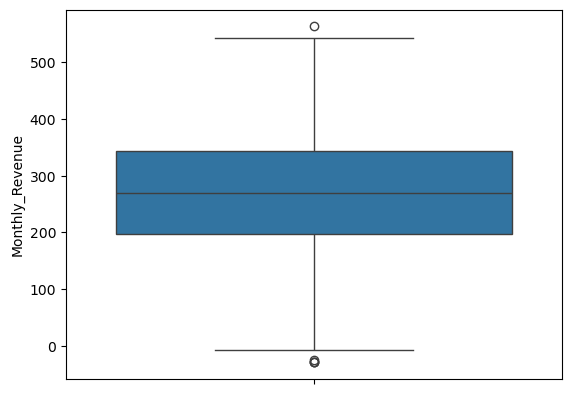

In [15]:
sns.boxplot(df['Monthly_Revenue'])

In [16]:
Q1 = df['Monthly_Revenue'].quantile(0.25)
Q3 = df['Monthly_Revenue'].quantile(0.75)
IQR = Q3 - Q1

df['Monthly_Revenue'] = df['Monthly_Revenue'].clip(lower=Q1 - 1.5 * IQR, upper=Q3 + 1.5 * IQR)

for col in num_col:
    outliers = detect_outliers(df, col)
    print(f"Outlier in {col} after cleaning: {df[outliers].shape[0]}")

Outlier in Number_of_Customers after cleaning: 0
Outlier in Menu_Price after cleaning: 0
Outlier in Marketing_Spend after cleaning: 0
Outlier in Average_Customer_Spending after cleaning: 0
Outlier in Promotions after cleaning: 0
Outlier in Reviews after cleaning: 0
Outlier in Monthly_Revenue after cleaning: 0


<Axes: ylabel='Monthly_Revenue'>

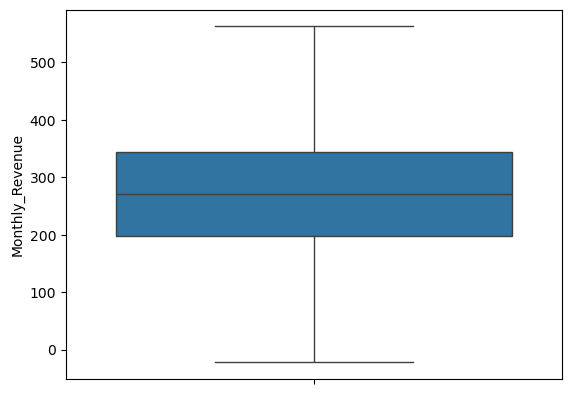

In [17]:
sns.boxplot(df['Monthly_Revenue'])

### 5. Encode Categorical Data

In [19]:
df=pd.get_dummies(df, drop_first=True)

In [20]:
df.head()

,Number_of_Customers,Menu_Price,Marketing_Spend,Average_Customer_Spending,Promotions,Reviews,Monthly_Revenue,Cuisine_Type_Italian,Cuisine_Type_Japanese,Cuisine_Type_Mexican
0,61,43.117635,12.663793,36.236133,0,45,350.912040,False,True,False
1,24,40.020077,4.577892,17.952562,0,36,221.319091,True,False,False
2,81,41.981485,4.652911,22.600420,1,91,326.529763,False,True,False
3,70,43.005307,4.416053,18.984098,1,59,348.190573,True,False,False
4,30,17.456199,3.475052,12.766143,1,30,185.009121,True,False,False


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Number_of_Customers        1000 non-null   int64  
 1   Menu_Price                 1000 non-null   float64
 2   Marketing_Spend            1000 non-null   float64
 3   Average_Customer_Spending  1000 non-null   float64
 4   Promotions                 1000 non-null   int64  
 5   Reviews                    1000 non-null   int64  
 6   Monthly_Revenue            1000 non-null   float64
 7   Cuisine_Type_Italian       1000 non-null   bool   
 8   Cuisine_Type_Japanese      1000 non-null   bool   
 9   Cuisine_Type_Mexican       1000 non-null   bool   
dtypes: bool(3), float64(4), int64(3)
memory usage: 57.7 KB


### 6. Split the Dataset

In [23]:
from sklearn.model_selection import train_test_split

# Define features and target variable
X = df.drop('Monthly_Revenue', axis=1) # All features except the target
y = df['Monthly_Revenue']

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### 7. Apply Machine Learning Models

In [25]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import GridSearchCV


lr = LinearRegression(n_jobs=-1)
lr.fit(X_train, y_train)

LinearRegression(n_jobs=-1)

In [26]:
y_pred_lr_test = lr.predict(X_test)
y_pred_lr_train = lr.predict(X_train)

In [27]:
r2_score(y_train,y_pred_lr_train)

0.6870254815259292

In [28]:
r2_score(y_test,y_pred_lr_test)

0.6745111152275178

In [29]:
from sklearn.metrics import mean_absolute_error
mae_lr_test = mean_absolute_error(y_test, y_pred_lr_test)
print(f"Linear Regression MAE (Test): {mae_lr_test}")

Linear Regression MAE (Test): 47.13928323696433


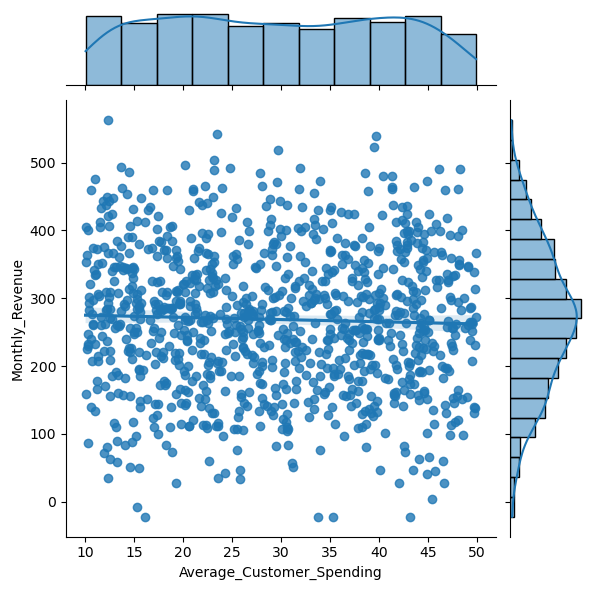

In [30]:
sns.jointplot(df,x='Average_Customer_Spending',y='Monthly_Revenue',kind='reg')

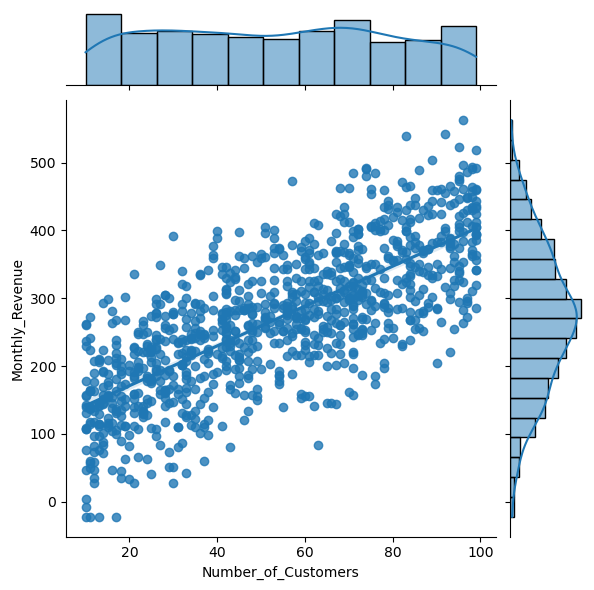

In [31]:
sns.jointplot(df,x='Number_of_Customers',y='Monthly_Revenue',kind='reg')

In [32]:
from sklearn.tree import DecisionTreeRegressor
dt = DecisionTreeRegressor(random_state=42)

In [33]:
param_grid = {
    'max_depth': [3, 5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(estimator=dt, param_grid=param_grid, 
                           cv=5, n_jobs=-1, verbose=1, scoring='neg_mean_squared_error')

In [34]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 45 candidates, totalling 225 fits


GridSearchCV(cv=5, estimator=DecisionTreeRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [3, 5, 10, 15, None],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]},
             scoring='neg_mean_squared_error', verbose=1)

In [35]:
best_model_dt = grid_search.best_estimator_
best_model_dt

DecisionTreeRegressor(max_depth=5, min_samples_leaf=4, random_state=42)

In [36]:
y_pred_test = best_model_dt.predict(X_test)
y_pred_train = best_model_dt.predict(X_train)

In [37]:
r2_score(y_train, y_pred_train)

0.7272851728877392

In [38]:
r2_score(y_test, y_pred_test)

0.5738371483598161

In [39]:
y_pred_dt_test = best_model_dt.predict(X_test)
from sklearn.metrics import mean_absolute_error

mae_dt_test = mean_absolute_error(y_test, y_pred_dt_test)
print(f"Decision Tree MAE (Test): {mae_dt_test}")

Decision Tree MAE (Test): 55.469093138157625


In [40]:
from sklearn.ensemble import RandomForestRegressor

In [41]:
rf = RandomForestRegressor(random_state=42)

In [42]:
param_grid={
    'n_estimators':[1,100,250,500,1000],
    'max_features': [2,5,10],
    'min_samples_split': [2,5,10]
}

In [43]:
grid_search = GridSearchCV(rf,param_grid,n_jobs=-1,cv=5)

In [44]:
grid_search.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_features': [2, 5, 10],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [1, 100, 250, 500, 1000]})

In [45]:
grid_search.best_params_

{'max_features': 5, 'min_samples_split': 10, 'n_estimators': 100}

In [46]:
best_model_rf = grid_search.best_estimator_

In [47]:
y_pred_rf_train = best_model_rf.predict(X_train)
y_pred_rf_test = best_model_rf.predict(X_test)

In [48]:
r2_score(y_train,y_pred_rf_train)

0.8730997106497436

In [49]:
r2_score(y_test,y_pred_rf_test)

0.6413034354875852

In [50]:
mae_rf_test = mean_absolute_error(y_test, y_pred_rf_test)
print(f"Random Forest MAE (Test): {mae_rf_test}")

Random Forest MAE (Test): 50.71534354069385


### The Random Forest model is likely better because:

It reduces overfitting.
It has a lower MAE and higher R² compared to the Decision Tree.
It is more stable and robust across different datasets.


### Recommendations for Future Improvements:
Hyperparameter Tuning.
Feature Engineering.
Handling Outliers.
Data Augmentation.

--- Suhana Bagwan